In [16]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
print("Shape of the dataset:", df.shape)
print("Number of fraudulent transactions:", df['Class'].sum())
print("Number of non-fraudulent transactions:", len(df) - df['Class'].sum())
print("Data types of the columns:\n", df.dtypes)

Shape of the dataset: (284807, 31)
Number of fraudulent transactions: 492
Number of non-fraudulent transactions: 284315
Data types of the columns:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [19]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [20]:
print("\nClass distribution:")
print(df["Class"].value_counts())

fraud = df["Class"].sum()
non_fraud = len(df) - fraud
print("\nClass ratio (fraudulent to non-fraudulent):")
print(fraud / non_fraud)

print("\nClass ratio (proportion):")
print(df["Class"].value_counts(normalize=True))


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class ratio (fraudulent to non-fraudulent):
0.0017304750013189597

Class ratio (proportion):
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [21]:
#Duplicate check
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 1081


In [22]:
# remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)
print("\nClass distribution after duplicate removal:\n", df["Class"].value_counts())

Shape after duplicate removal: (283726, 31)

Class distribution after duplicate removal:
 Class
0    283253
1       473
Name: count, dtype: int64


In [27]:
# separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

In [26]:
#Train/test split with stratification

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


In [ ]:
#Feature scaling analysis
df[["Time", "Amount"]].describe()

,Time,Amount
count,283726.000000,283726.000000
mean,94811.077600,88.472687
std,47481.047891,250.399437
min,0.000000,0.000000
25%,54204.750000,5.600000
50%,84692.500000,22.000000
75%,139298.000000,77.510000
max,172792.000000,25691.160000


# Scaling decision
# Times goes up to about 25691
# Amount goes up to about 25691
# But many v1 to v28 values are usually much smaller and coverd around zero

/*
Why this matters

Some models are very sensitive to feature scale, especially:

Logistic Regression
SVM
MLP / Neural Network

These models work better when features are on roughly similar ranges.

If you do not scale:

large-value features like Time may influence optimization too much
gradient-based learning becomes less stable
distance-based behavior in SVM becomes distorted
model may learn poorly or unfairly weight features

*/

Why StandardScaler

StandardScaler converts values into approximately:

mean = 0
standard deviation = 1

So after scaling:

Time
Amount

become centered and comparable to the other PCA features.


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

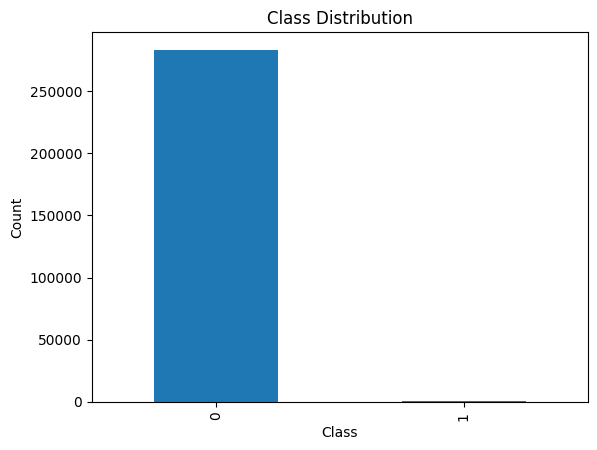

In [30]:
#Class distribution bar chart
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


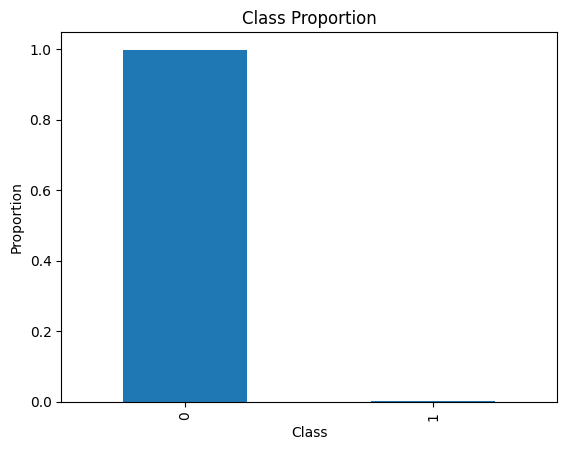

In [31]:
#Class proportion pie chart or percentage bar

df["Class"].value_counts(normalize=True).plot(kind="bar")
plt.title("Class Proportion")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.show()

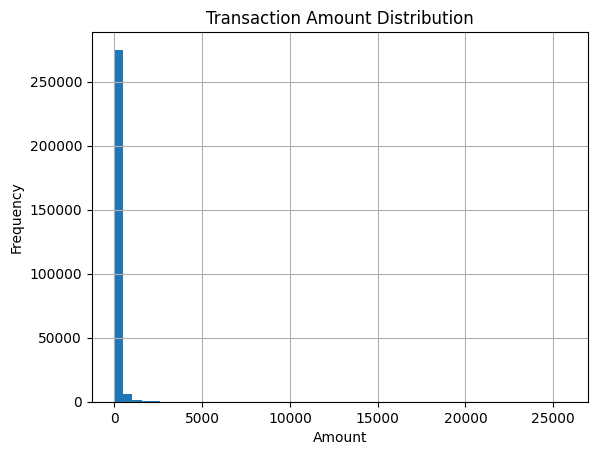

In [32]:
#Histogram of Amount
df["Amount"].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

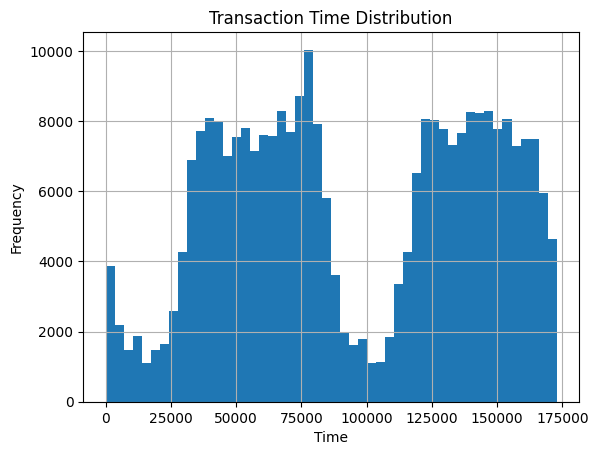

In [33]:
#Histogram of Time
df["Time"].hist(bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

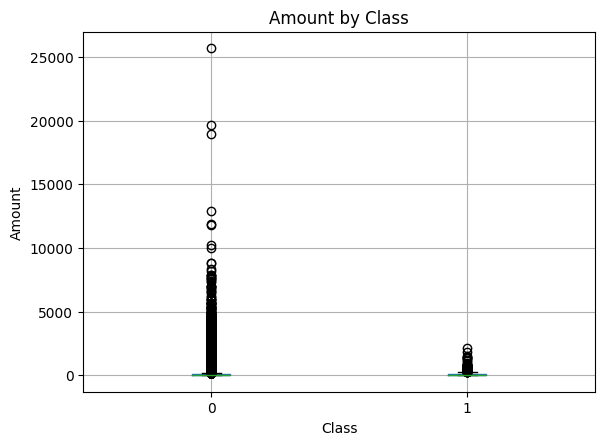

In [34]:
#Fraud vs non-fraud Amount boxplot

df.boxplot(column="Amount", by="Class")
plt.title("Amount by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

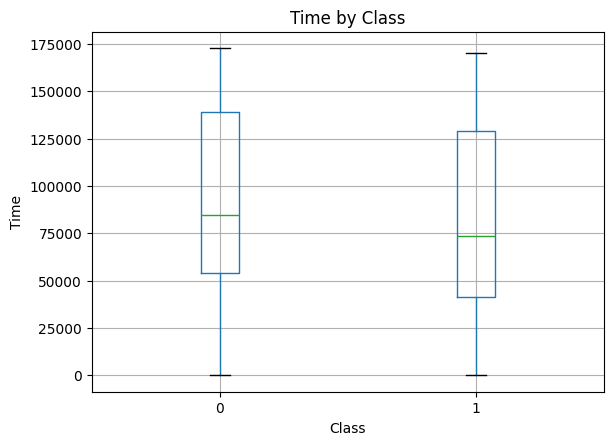

In [35]:
#Fraud vs non-fraud Time boxplot
df.boxplot(column="Time", by="Class")
plt.title("Time by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Time")
plt.show()

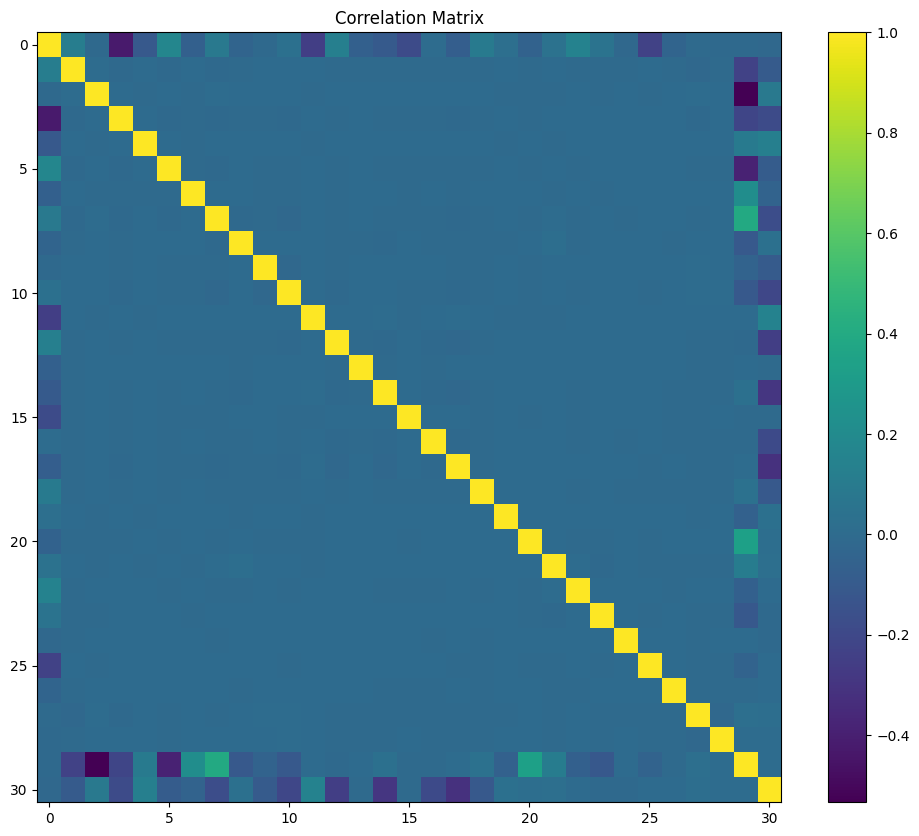

In [ ]:
#Correlation matrix heatmap
corr = df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


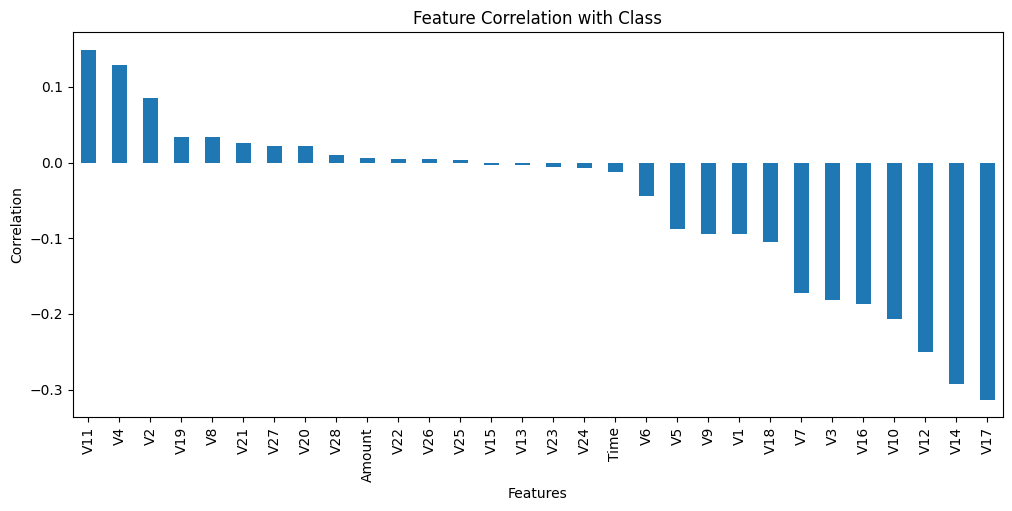

In [ ]:
#A full heatmap look crowded, so we can focus on correlation with the target variable "Class"
class_corr = df.corr()["Class"].sort_values(ascending=False)
print(class_corr)

class_corr.drop("Class").plot(kind="bar", figsize=(12,5))
plt.title("Feature Correlation with Class")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.show()